<a href="https://colab.research.google.com/github/22495521/99-multiplication-table/blob/main/CNN_test.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [21]:
# 掛載 Google Drive，讓 Colab 能讀取雲端硬碟裡的檔案
from google.colab import drive
drive.mount('/content/drive')

# 把 Drive 上的 zip 複製到 Colab 本機（/content）
# 在本機解壓和讀檔都比直接在 Drive 上操作快很多
!cp "/content/drive/MyDrive/colab_file/handwriting-data.zip" /content/

# 把 zip 解壓到 /content，解壓後資料位於 /content/data/...
# -q：安靜模式，不逐一列出解壓的檔案
# -o：強制覆寫已存在的檔案，避免出現互動提示
# -d：指定解壓的目的資料夾
!unzip -q -o /content/handwriting-data.zip -d /content

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [22]:

import torch
import torchvision
from torchvision.transforms import v2

In [23]:
IMG_SIZE = 28
train_dir = "/content/data/handwriting/augmented_images/augmented_images1"
test_dir  = "/content/data/handwriting/handwritten-english-characters-and-digits/combined_folder/test"
batch_size = 64

train_tf = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(1),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.RandomCrop(IMG_SIZE, padding=4),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
])

test_tf = v2.Compose([
    v2.ToImage(),
    v2.Grayscale(1),
    v2.Resize((IMG_SIZE, IMG_SIZE)),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize((0.5,), (0.5,)),
])

trainset = datasets.ImageFolder(train_dir, transform=train_tf)
testset  = datasets.ImageFolder(test_dir,  transform=test_tf)

# 將 num_workers 設為 0 並加上 pin_memory=True 以加速 GPU 傳輸，避免 Colab 多執行緒讀檔卡頓
train_loader = DataLoader(trainset, batch_size=batch_size, shuffle=True, num_workers=0, pin_memory=True)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size, shuffle=False, num_workers=0, pin_memory=True)

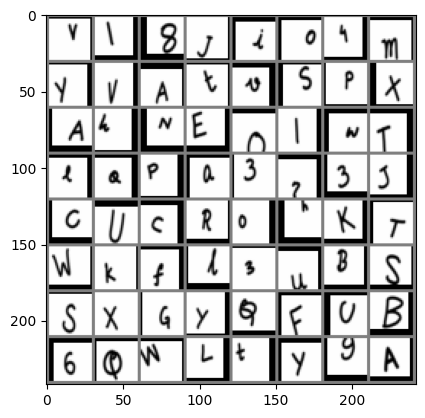

In [24]:
import matplotlib.pyplot as plt
import numpy as np

# functions to show an image


def imshow(img):
    img = img / 2 + 0.5     # unnormalize
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(train_loader)
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images))


In [25]:
import torch.nn as nn
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 6, 5)
        self.pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(6, 16, 5)
        self.fc1 = nn.Linear(16 * 4 * 4, 120)
        self.fc2 = nn.Linear(120, 84)
        self.fc3 = nn.Linear(84, 62)

    def forward(self, x):
        x = self.pool(F.relu(self.conv1(x)))
        x = self.pool(F.relu(self.conv2(x)))
        x = torch.flatten(x, 1) # flatten all dimensions except batch
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)
        return x


net = Net()

In [26]:
import torch.optim as optim

criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(net.parameters(), lr=0.01)

# 檢查並設定 GPU/CUDA 裝置
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"使用裝置: {device}")

使用裝置: cuda


In [ ]:
# 將模型送至指定裝置
net = net.to(device)

# 開始訓練
epochs = 5
print("開始訓練...")

for epoch in range(epochs):
    net.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for i, (images, labels) in enumerate(train_loader):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()

        # 前向傳播
        outputs = net(images)
        loss = criterion(outputs, labels)

        # 反向傳播與優化
        loss.backward()
        optimizer.step()

        # 累加統計值
        running_loss += loss.item() * images.size(0)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        # 每 100 個 Batch 印出一次進度，避免看起來卡住
        if (i + 1) % 100 == 0:
            print(f"Epoch [{epoch+1}/{epochs}], Step [{i+1}/{len(train_loader)}], Loss: {loss.item():.4f}, Acc: {100. * correct / total:.2f}%")

    train_loss = running_loss / len(train_loader.dataset)
    train_acc = 100. * correct / total
    print(f"===> Epoch [{epoch+1}/{epochs}] 結束 - 平均損失: {train_loss:.4f}, 平均準確度: {train_acc:.2f}%\n")

print("訓練流程執行完畢！")

開始訓練...
